In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
df = pd.read_csv("/content/train-data (1).csv")

In [194]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 6019
Columns: 14


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [195]:
df.columns

Index(['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power',
       'Seats', 'New_Price', 'Price'],
      dtype='object')

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [197]:
df.drop(columns=["Unnamed: 0", "New_Price"], inplace=True)

In [198]:
df.describe()

,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,2013.358199,5.873838e+04,5.278735,9.479468
std,3.269742,9.126884e+04,0.808840,11.187917
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.640000
75%,2016.000000,7.300000e+04,5.000000,9.950000
max,2019.000000,6.500000e+06,10.000000,160.000000


In [199]:
df.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,36
Power,36


In [200]:
df.duplicated().sum()

np.int64(0)

data cleaning

convert the milage ,engine ,power into the numneric because it is contain the unit values

In [201]:
df["Mileage"].head(10)

,Mileage
0,26.6 km/kg
1,19.67 kmpl
2,18.2 kmpl
3,20.77 kmpl
4,15.2 kmpl
5,21.1 km/kg
6,23.08 kmpl
7,11.36 kmpl
8,20.54 kmpl
9,22.3 kmpl


In [202]:
#converthe milage unit into the numneric
df["Mileage"].unique()[:20]

array(['26.6 km/kg', '19.67 kmpl', '18.2 kmpl', '20.77 kmpl', '15.2 kmpl',
       '21.1 km/kg', '23.08 kmpl', '11.36 kmpl', '20.54 kmpl',
       '22.3 kmpl', '21.56 kmpl', '16.8 kmpl', '25.2 kmpl', '12.7 kmpl',
       '0.0 kmpl', '13.5 kmpl', '25.8 kmpl', '28.4 kmpl', '20.45 kmpl',
       '14.84 kmpl'], dtype=object)

In [203]:
df["Mileage"] = df["Mileage"].str.extract(r"([\d.]+)")[0].astype(float)

In [204]:
df["Mileage"].head(10)


,Mileage
0,26.60
1,19.67
2,18.20
3,20.77
4,15.20
5,21.10
6,23.08
7,11.36
8,20.54
9,22.30


In [205]:
df["Mileage"].dtype

dtype('float64')

In [206]:
df["Engine"].head(10)

,Engine
0,998 CC
1,1582 CC
2,1199 CC
3,1248 CC
4,1968 CC
5,814 CC
6,1461 CC
7,2755 CC
8,1598 CC
9,1248 CC


In [207]:
#convert the oject cc into the numeric
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.extract(r"([\d.]+)")[0]
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")

In [208]:
df["Engine"].head(10)

,Engine
0,998.0
1,1582.0
2,1199.0
3,1248.0
4,1968.0
5,814.0
6,1461.0
7,2755.0
8,1598.0
9,1248.0


In [209]:
df["Engine"].dtype

dtype('float64')

In [210]:
df["Engine"].isnull().sum()

np.int64(36)

In [211]:
df["Power"].head(10)

,Power
0,58.16 bhp
1,126.2 bhp
2,88.7 bhp
3,88.76 bhp
4,140.8 bhp
5,55.2 bhp
6,63.1 bhp
7,171.5 bhp
8,103.6 bhp
9,74 bhp


In [212]:
#change the unit of the power
df["Power"].unique()[:30]

array(['58.16 bhp', '126.2 bhp', '88.7 bhp', '88.76 bhp', '140.8 bhp',
       '55.2 bhp', '63.1 bhp', '171.5 bhp', '103.6 bhp', '74 bhp',
       '103.25 bhp', '116.3 bhp', '187.7 bhp', '115 bhp', '175.56 bhp',
       '98.6 bhp', '83.8 bhp', '167.62 bhp', '190 bhp', '88.5 bhp',
       '177.01 bhp', '80 bhp', '67.1 bhp', '102 bhp', '108.45 bhp',
       '138.1 bhp', '184 bhp', '179.5 bhp', '103.5 bhp', '64 bhp'],
      dtype=object)

In [213]:
df[df["Power"].astype(str).str.contains("null", case=False, na=False)]["Power"].value_counts()

,count
Power,
null bhp,107


In [214]:
df["Power"] = pd.to_numeric(
    df["Power"]
      .astype(str)
      .str.extract(r"([\d.]+)")[0],
    errors="coerce"
)

In [215]:
df["Power"].head(10)

,Power
0,58.16
1,126.20
2,88.70
3,88.76
4,140.80
5,55.20
6,63.10
7,171.50
8,103.60
9,74.00


In [216]:
df["Power"].isnull().sum()

np.int64(143)

In [217]:
df[["Mileage", "Engine", "Power", "Seats"]].isnull().sum()

,0
Mileage,2
Engine,36
Power,143
Seats,42


Missing Value Handling

In [218]:
df[["Mileage", "Engine", "Power", "Seats"]].median()

,0
Mileage,18.15
Engine,1493.00
Power,97.70
Seats,5.00


In [219]:
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

df["Engine"] = df["Engine"].fillna(df["Engine"].median())

df["Power"] = df["Power"].fillna(df["Power"].median())

In [220]:
df["Seats"].value_counts(dropna=False).sort_index()

,count
Seats,
0.0,1
2.0,16
4.0,99
5.0,5014
6.0,31
7.0,674
8.0,134
9.0,3
10.0,5


In [221]:
df["Seats"] = df["Seats"].replace(0, np.nan)

In [222]:
df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

In [223]:
df.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


finding outlier detection

In [224]:
df.nlargest(10, "Kilometers_Driven")[
    ["Name", "Year", "Kilometers_Driven", "Price"]
]

,Name,Year,Kilometers_Driven,Price
2328,BMW X5 xDrive 30d M Sport,2017,6500000,65.00
340,Skoda Octavia Ambition Plus 2.0 TDI AT,2013,775000,7.50
1860,Volkswagen Vento Diesel Highline,2013,720000,5.90
358,Hyundai i10 Magna 1.2,2009,620000,2.70
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,2015,480000,13.00
3092,Honda City i VTEC SV,2015,480000,5.00
4491,Hyundai i20 Magna Optional 1.2,2013,445000,4.45
3649,Tata Indigo LS,2008,300000,1.00
1528,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2005,299322,4.00
1975,Skoda Superb 1.8 TSI MT,2012,282000,3.30


In [225]:
df["Kilometers_Driven"].describe()

,Kilometers_Driven
count,6.019000e+03
mean,5.873838e+04
std,9.126884e+04
min,1.710000e+02
25%,3.400000e+04
50%,5.300000e+04
75%,7.300000e+04
max,6.500000e+06


Detect Outliers Using IQR

In [226]:
Q1 = df["Kilometers_Driven"].quantile(0.25)
Q3 = df["Kilometers_Driven"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 34000.0
Q3: 73000.0
IQR: 39000.0
Lower Bound: -24500.0
Upper Bound: 131500.0


In [227]:
km_outliers = df[
    (df["Kilometers_Driven"] < lower_bound) |
    (df["Kilometers_Driven"] > upper_bound)
]

print("Number of outliers:", len(km_outliers))

Number of outliers: 202


In [228]:
km_outliers["Kilometers_Driven"].describe()

,Kilometers_Driven
count,2.020000e+02
mean,2.099104e+05
std,4.522499e+05
min,1.317650e+05
25%,1.432948e+05
50%,1.557830e+05
75%,1.800000e+05
max,6.500000e+06


In [229]:
df[df["Kilometers_Driven"] > 500000][
    ["Name", "Year", "Kilometers_Driven", "Price"]
]

,Name,Year,Kilometers_Driven,Price
340,Skoda Octavia Ambition Plus 2.0 TDI AT,2013,775000,7.5
358,Hyundai i10 Magna 1.2,2009,620000,2.7
1860,Volkswagen Vento Diesel Highline,2013,720000,5.9
2328,BMW X5 xDrive 30d M Sport,2017,6500000,65.0


Remove extreme KM records

In [230]:
df = df[df["Kilometers_Driven"] <= 500000].copy()

In [231]:
df.reset_index(drop=True, inplace=True)

In [232]:
print("Dataset shape:", df.shape)
print("Maximum KM:", df["Kilometers_Driven"].max())

Dataset shape: (6015, 12)
Maximum KM: 480000


In [233]:
df[["Mileage", "Engine", "Power", "Seats", "Price"]].describe()

,Mileage,Engine,Power,Seats,Price
count,6015.000000,6015.000000,6015.000000,6015.000000,6015.000000
mean,18.134362,1620.297423,112.861932,5.277805,9.472289
std,4.582747,599.531965,53.265386,0.803715,11.168245
min,0.000000,72.000000,34.200000,2.000000,0.440000
25%,15.170000,1198.000000,78.000000,5.000000,3.500000
50%,18.150000,1493.000000,97.700000,5.000000,5.640000
75%,21.100000,1969.000000,138.030000,5.000000,9.950000
max,33.540000,5998.000000,560.000000,10.000000,160.000000


In [234]:
print("Mileage zero:", (df["Mileage"] == 0).sum())
print("Engine zero:", (df["Engine"] == 0).sum())
print("Power zero:", (df["Power"] == 0).sum())
print("Price zero:", (df["Price"] == 0).sum())

Mileage zero: 68
Engine zero: 0
Power zero: 0
Price zero: 0


Handle Zero Mileage

In [235]:
df["Mileage"] = df["Mileage"].replace(0, np.nan)

In [236]:
df["Mileage"].isnull().sum()

np.int64(68)

In [237]:


df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

In [238]:
print("Missing Mileage:", df["Mileage"].isnull().sum())
print("Zero Mileage:", (df["Mileage"] == 0).sum())
print("Median Mileage:", df["Mileage"].median())

Missing Mileage: 0
Zero Mileage: 0
Median Mileage: 18.2


In [239]:
df[df["Engine"] < 500][
    ["Name", "Year", "Fuel_Type", "Engine", "Power", "Seats", "Price"]
]

,Name,Year,Fuel_Type,Engine,Power,Seats,Price
4442,Mahindra E Verito D4,2016,Electric,72.0,41.0,5.0,13.0


Check categorical columns

In [240]:
categorical_columns = [
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Location
Location
Mumbai        790
Hyderabad     742
Kochi         651
Coimbatore    636
Pune          622
Delhi         554
Kolkata       534
Chennai       491
Jaipur        413
Bangalore     358
Ahmedabad     224
Name: count, dtype: int64

 Fuel_Type
Fuel_Type
Diesel      3202
Petrol      2745
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64

 Transmission
Transmission
Manual       4297
Automatic    1718
Name: count, dtype: int64

 Owner_Type
Owner_Type
First             4925
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64


Feature Engineering

Extract Car Brand from Name

In [241]:
df["Brand"] = df["Name"].str.split().str[0]

In [242]:
df["Brand"].value_counts()

,count
Brand,
Maruti,1211
Hyundai,1106
Honda,608
Toyota,411
Mercedes-Benz,318
Volkswagen,314
Ford,300
Mahindra,272
BMW,266


In [243]:
#convert the izuzu 2  cmpany into the 1 company
df["Brand"] = df["Brand"].replace("ISUZU", "Isuzu")

In [244]:
df["Brand"] = df["Brand"].replace("Land", "Land Rover")

In [245]:
df["Brand"].value_counts()

,count
Brand,
Maruti,1211
Hyundai,1106
Honda,608
Toyota,411
Mercedes-Benz,318
Volkswagen,314
Ford,300
Mahindra,272
BMW,266


Create Car_Age

In [246]:
df["Car_Age"] = df["Year"].max() - df["Year"]

In [247]:
df[["Year", "Car_Age"]].head(10)

,Year,Car_Age
0,2010,9
1,2015,4
2,2011,8
3,2012,7
4,2013,6
5,2012,7
6,2013,6
7,2016,3
8,2013,6
9,2012,7


In [248]:
print("Unique car names:", df["Name"].nunique())
print("Unique brands:", df["Brand"].nunique())

Unique car names: 1877
Unique brands: 30


In [249]:
df["Name"].value_counts().head(20)

,count
Name,
Mahindra XUV500 W8 2WD,49
Maruti Swift VDI,45
Maruti Swift Dzire VDI,34
Honda City 1.5 S MT,34
Maruti Swift VDI BSIV,31
Maruti Ritz VDi,30
Hyundai i10 Sportz,30
Toyota Fortuner 3.0 Diesel,29
Hyundai Grand i10 Sportz,27


In [250]:
df["Model"] = df["Name"].str.split().str[1]

print("Unique models:", df["Model"].nunique())
df["Model"].value_counts().head(30)

Unique models: 213


,count
Model,
Swift,353
City,270
i20,247
Verna,170
Innova,164
Grand,156
i10,155
Wagon,154
Polo,151


In [251]:
df["Model"] = df["Name"].str.split().str[1]

In [252]:
df.drop(columns=["Model"], inplace=True)

In [253]:
df.drop(columns=["Name", "Year"], inplace=True)

In [254]:
df.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,Mumbai,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Maruti,9
1,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,4
2,Chennai,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,8
3,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,7
4,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,6


In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6015 entries, 0 to 6014
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           6015 non-null   object 
 1   Kilometers_Driven  6015 non-null   int64  
 2   Fuel_Type          6015 non-null   object 
 3   Transmission       6015 non-null   object 
 4   Owner_Type         6015 non-null   object 
 5   Mileage            6015 non-null   float64
 6   Engine             6015 non-null   float64
 7   Power              6015 non-null   float64
 8   Seats              6015 non-null   float64
 9   Price              6015 non-null   float64
 10  Brand              6015 non-null   object 
 11  Car_Age            6015 non-null   int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 564.0+ KB


EDA

Target Variable: Price

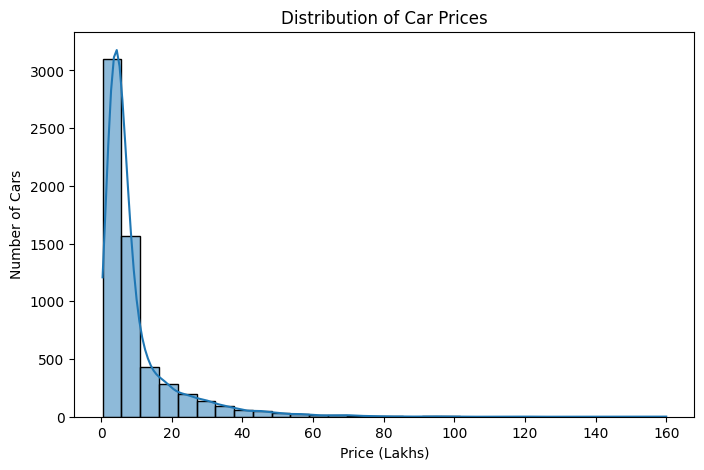

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

In [257]:
print("Skewness:", df["Price"].skew())

Skewness: 3.3366548988495697


Brand vs Price

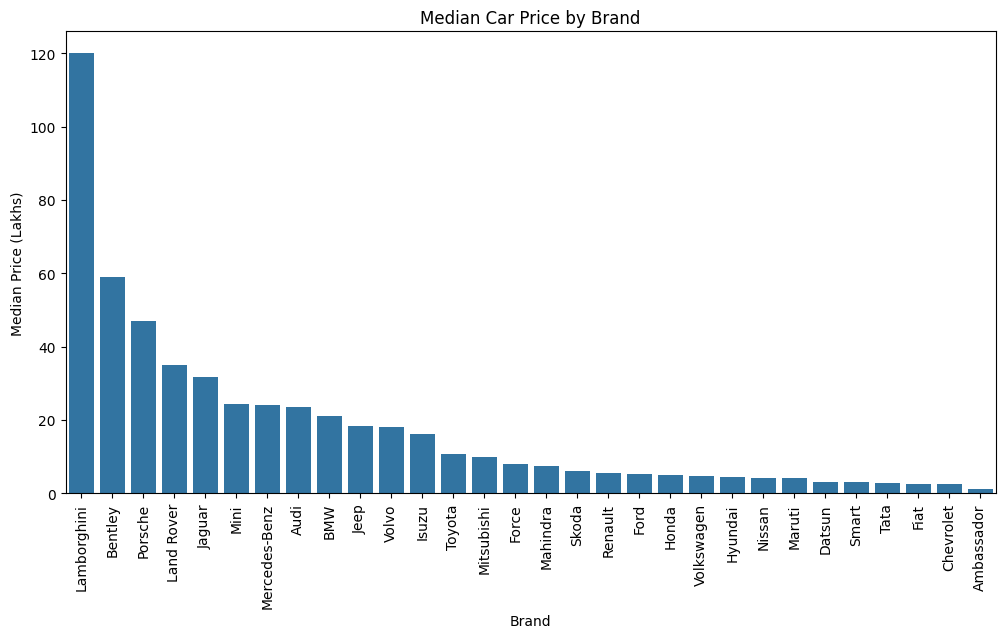

In [258]:
brand_price = (
    df.groupby("Brand")["Price"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=90)
plt.title("Median Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Median Price (Lakhs)")
plt.show()

uxury brands have much higher median used-car prices. In your dataset, Lamborghini is highest, followed by brands such as Bentley and Porsche, while mass-market brands are much lower.

Car Age vs Price.

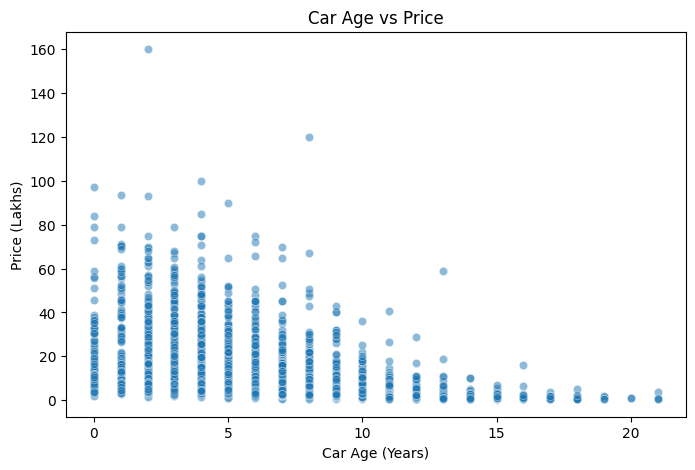

In [259]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Price",
    alpha=0.5
)

plt.title("Car Age vs Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price (Lakhs)")
plt.show()

As Car_Age increases, Price generally decreases.

Power vs Price.

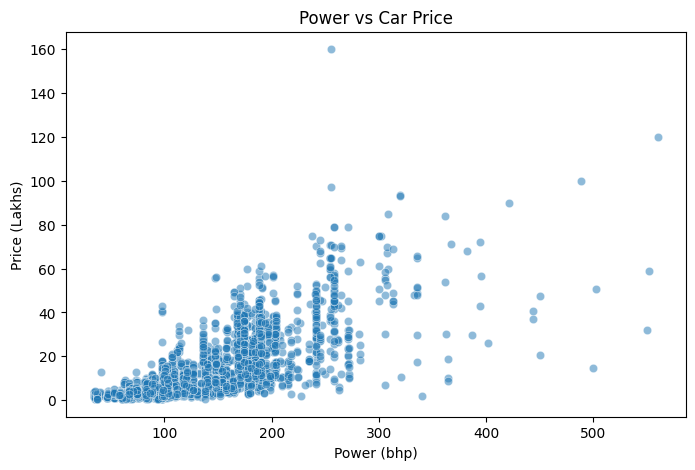

In [260]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Power",
    y="Price",
    alpha=0.5
)

plt.title("Power vs Car Price")
plt.xlabel("Power (bhp)")
plt.ylabel("Price (Lakhs)")
plt.show()

Higher Power → Higher Car Price

Correlation Heatmap

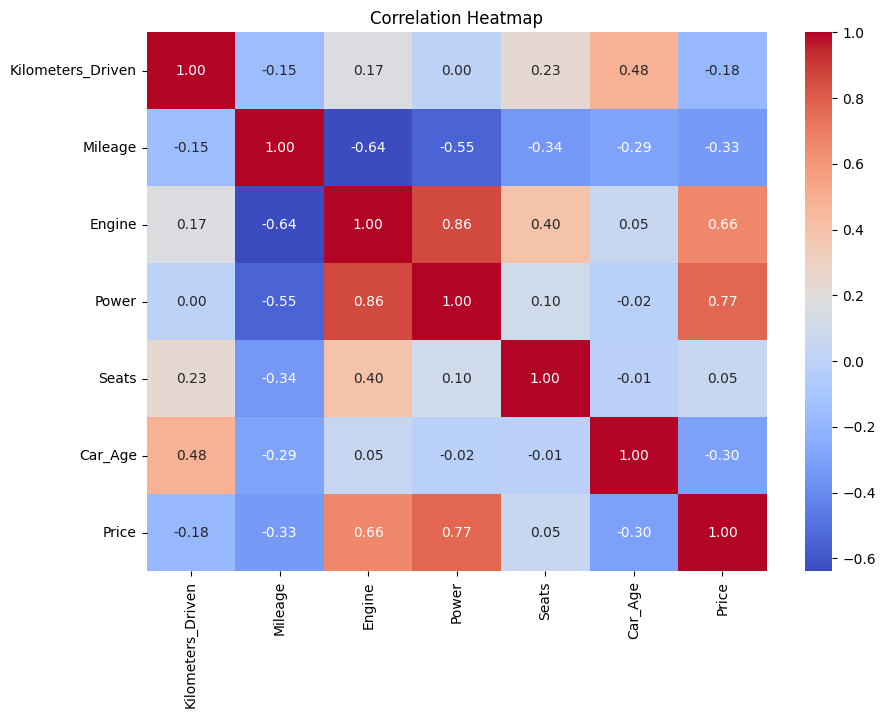

In [261]:
numeric_cols = [
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Car_Age",
    "Price"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

The correlation analysis showed that Power and Engine have the strongest positive relationships with car price, while Car Age, Mileage, and Kilometers Driven have negative relationships with price.

Data Preparation & Encoding

In [262]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [263]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6015, 11)
y shape: (6015,)


In [264]:
#IDENTIFY CATEGORICAL AND NUMERICAL COLUM
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

Numerical columns:
['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']


In [265]:
#TRAIN AND SLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [266]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4812, 11)
X_test: (1203, 11)
y_train: (4812,)
y_test: (1203,)


In [267]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [268]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [269]:
print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape:", X_test_encoded.shape)

X_train encoded shape: (4812, 57)
X_test encoded shape: (1203, 57)


Model Training & Comparison

In [270]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np

CRATE MODEL

In [271]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

Train all models using a loop

In [272]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_encoded, y_train)

    # Predict
    y_pred = model.predict(X_test_encoded)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [273]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
4,XGBoost,1.311597,2.846066,0.929829
2,Random Forest,1.405893,2.946765,0.924775
3,Gradient Boosting,1.746635,3.362025,0.902080
1,Decision Tree,1.949938,4.180184,0.848623
0,Linear Regression,3.367332,5.214461,0.764448


  XGBoost	1.312	2.846	0.930
	Random Forest	1.406	2.947	0.925
	Gradient Boosting	1.747	3.362	0.902
  Decision Tree	1.950	4.180	0.849
  Linear Regression	3.367	5.214	0.764

MODEL EVALUVATION

In [274]:
xgb_model = models["XGBoost"]

train_pred = xgb_model.predict(X_train_encoded)
test_pred = xgb_model.predict(X_test_encoded)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("XGBoost Training R2:", train_r2)
print("XGBoost Testing R2 :", test_r2)
print("R2 Gap             :", train_r2 - test_r2)

XGBoost Training R2: 0.9956621738669283
XGBoost Testing R2 : 0.9298288378108562
R2 Gap             : 0.06583333605607211


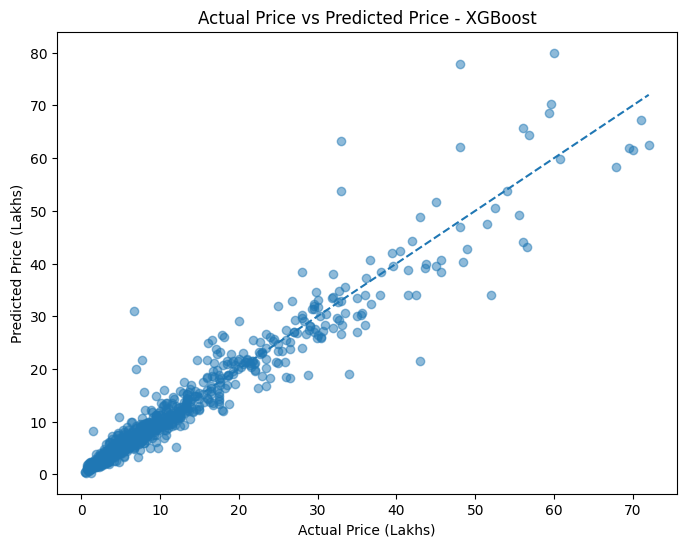

In [275]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual Price vs Predicted Price - XGBoost")

plt.show()

Residual Analysis

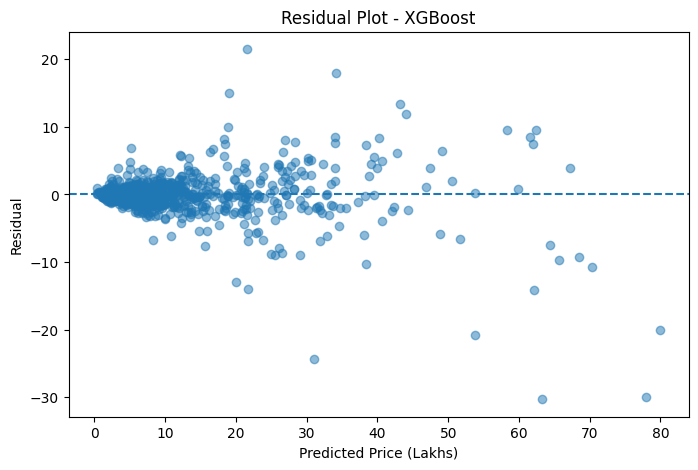

In [276]:
residuals = y_test - test_pred

plt.figure(figsize=(8, 5))

plt.scatter(test_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residual")
plt.title("Residual Plot - XGBoost")

plt.show()

In [277]:
print("Mean Residual:", residuals.mean())

Mean Residual: -0.07325577664553676


HYPER PARAMETER TUNING


In [278]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [279]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation R2:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Best Cross Validation R2:
0.9109886109589252




Test the Tuned Model

In [280]:
best_xgb = random_search.best_estimator_

# Predictions
tuned_train_pred = best_xgb.predict(X_train_encoded)
tuned_test_pred = best_xgb.predict(X_test_encoded)

# Metrics
tuned_train_r2 = r2_score(y_train, tuned_train_pred)
tuned_test_r2 = r2_score(y_test, tuned_test_pred)

tuned_mae = mean_absolute_error(y_test, tuned_test_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_test_pred))

print("Tuned XGBoost Results")
print("Training R2:", tuned_train_r2)
print("Testing R2 :", tuned_test_r2)
print("R2 Gap     :", tuned_train_r2 - tuned_test_r2)
print("MAE        :", tuned_mae)
print("RMSE       :", tuned_rmse)

Tuned XGBoost Results
Training R2: 0.9989937045875982
Testing R2 : 0.9355420555378848
R2 Gap     : 0.06345164904971334
MAE        : 1.2469411985153769
RMSE       : 2.727745421539483


model prediction

In [281]:
def predict_car_price(car_data):

    # Convert input dictionary to DataFrame
    car_df = pd.DataFrame([car_data])

    # Apply same preprocessing used during training
    car_encoded = preprocessor.transform(car_df)

    # Predict using tuned XGBoost
    prediction = best_xgb.predict(car_encoded)

    return prediction[0]

sample example

In [282]:
sample_car = {
    "Location": "Kochi",
    "Kilometers_Driven": 50000,
    "Fuel_Type": "Diesel",
    "Transmission": "Manual",
    "Owner_Type": "First",
    "Mileage": 18.0,
    "Engine": 1500.0,
    "Power": 100.0,
    "Seats": 5.0,
    "Brand": "Hyundai",
    "Car_Age": 4
}

predicted_price = predict_car_price(sample_car)

print("Predicted Car Price:", round(predicted_price, 2), "Lakhs")

Predicted Car Price: 5.71 Lakhs


Save the Final Model + Preprocessor

In [283]:
import pickle

with open("car_price_model.pkl", "wb") as file:
    pickle.dump(best_xgb, file)

print("Model saved successfully!")

Model saved successfully!


In [284]:
with open("preprocessor.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [285]:
import os

print("Model exists:", os.path.exists("car_price_model.pkl"))
print("Preprocessor exists:", os.path.exists("preprocessor.pkl"))

Model exists: True
Preprocessor exists: True


Load Them Back and Test

In [286]:
with open("car_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("preprocessor.pkl", "rb") as file:
    loaded_preprocessor = pickle.load(file)

print("Model and preprocessor loaded successfully!")

Model and preprocessor loaded successfully!


In [287]:
sample_df = pd.DataFrame([sample_car])

sample_encoded = loaded_preprocessor.transform(sample_df)

loaded_prediction = loaded_model.predict(sample_encoded)

print(
    "Prediction from loaded model:",
    round(loaded_prediction[0], 2),
    "Lakhs"
)

Prediction from loaded model: 5.71 Lakhs
